# tune_integrated_umap — per-model / integrated UMAP の調整 notebook

`runs/` の 20 構成（5 ODE branch × 4 variant）の generated を使い、**2 系統**の UMAP を作る。
**既存 pipeline / viz は変更しない**（`integrated_umap_utils.py` のみ使用、torch 不要）。

- **A) per-model**: 各 config_label について real(Superclass色) + その model の generated(**赤固定**)で個別 UMAP（20枚 + facets）
- **B) integrated**: real(全部) + 全 model の generated を 1 つの UMAP。overlay 4 種（real_annotation / origin /
  by_model / **branch=marker × variant=color**）+ 横並び summary

セル: (1) config (2) discover (3) save selection (4) real load+配色 (5) **A per-model** (6) **B integrated** (7) 一覧。


In [1]:
# 1) imports and config
import os, sys, json, importlib
from datetime import datetime
import pandas as pd

_here = os.getcwd()
if not os.path.exists(os.path.join(_here, "integrated_umap_utils.py")):
    for cand in (_here, os.path.join(_here, "integrated_analysis")):
        if os.path.exists(os.path.join(cand, "integrated_umap_utils.py")):
            _here = cand; break
sys.path.insert(0, _here)
import integrated_umap_utils as U
importlib.reload(U)

RUNS_ROOT   = "../runs"
OUTPUT_ROOT = "outputs"
RUN_SUFFIX  = "ALL100k"
DATA_DIR    = U.DEFAULT_DATA_DIR
SEED        = 0

# ---- per-model 用設定（A）----
PER_MODEL_REAL_CELLS = 50000
PER_MODEL_GEN_CELLS  = 3000

# ---- integrated 用設定（B）----
INTEGRATED_REAL_CELLS    = 0     # 0 or None = 全 real（~150k）
INTEGRATED_GEN_PER_MODEL = 500

# annotation（real の色付け列）。Superclass を優先
ANNOTATION_PRIORITY = ["Superclass", "Subclass", "ClassAnn", "celltype", "final_annotation"]
N_PCS = 50; N_NEIGHBORS = 15; MIN_DIST = 0.5

# ---- LIGHT_MODE: notebook を軽く回す（フル品質は False）----
LIGHT_MODE = True
if LIGHT_MODE:
    PER_MODEL_REAL_CELLS  = 4000
    INTEGRATED_REAL_CELLS = 20000
    print("LIGHT_MODE=True -> per_model_real=4000, integrated_real=20000 (フルは False)")
print("data_dir ->", U.resolve_path(DATA_DIR))


LIGHT_MODE=True -> per_model_real=4000, integrated_real=20000 (フルは False)
data_dir -> /Users/cls-lab/Git/scDiffusionODE/work/20260215_embryonic/data/Embryonic.h5ad


In [2]:
# 2) discover latest runs
selected, skipped = U.select_runs(RUNS_ROOT, RUN_SUFFIX)
print(f"selected={len(selected)}  skipped={len(skipped)}\n")
for L, r in selected.items():
    print(f"  {L:32s} step={r['checkpoint_step']:>7} ({r['checkpoint_kind']}) <- {r['run_dir_rel']}")
for L, v in skipped.items():
    print(f"  SKIP {L:32s} {v['reason']}")


selected=20  skipped=0

  geneode__none                    step=      2 (model) <- runs/geneode__none/20260617_175644
  geneode__ratio_reg               step=      2 (model) <- runs/geneode__ratio_reg/20260617_175825
  geneode__scale_model_x           step=      2 (model) <- runs/geneode__scale_model_x/20260617_180006
  geneode__scale_model_ml_emb      step=      2 (model) <- runs/geneode__scale_model_ml_emb/20260617_180146
  lowrank__none                    step=      2 (model) <- runs/lowrank__none/20260617_180325
  lowrank__ratio_reg               step=      2 (model) <- runs/lowrank__ratio_reg/20260617_180459
  lowrank__scale_model_x           step=      2 (model) <- runs/lowrank__scale_model_x/20260617_180632
  lowrank__scale_model_ml_emb      step=      2 (model) <- runs/lowrank__scale_model_ml_emb/20260617_180805
  lincomb__none                    step=      2 (model) <- runs/lincomb__none/20260617_180937
  lincomb__ratio_reg               step=      2 (model) <- runs/lincomb__r

In [3]:
# 3) save selected run config
OUT_DIR = os.path.join(OUTPUT_ROOT, U.now_stamp())
os.makedirs(OUT_DIR, exist_ok=True)
created_at = datetime.now().isoformat(timespec="seconds")
U.save_run_config(OUT_DIR, dict(
    runs_root=RUNS_ROOT, output_root=OUTPUT_ROOT, run_suffix=RUN_SUFFIX, data_dir=DATA_DIR, seed=SEED,
    per_model_real_cells=PER_MODEL_REAL_CELLS, per_model_gen_cells=PER_MODEL_GEN_CELLS,
    integrated_real_cells=INTEGRATED_REAL_CELLS, integrated_gen_per_model=INTEGRATED_GEN_PER_MODEL,
    n_pcs=N_PCS, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, light_mode=LIGHT_MODE,
    created_at=created_at, source="notebook"))
cfg = U.save_selection_metadata(
    OUT_DIR, selected, skipped, runs_root=RUNS_ROOT, run_suffix=RUN_SUFFIX,
    data_dir=DATA_DIR, data_dir_resolved=U.resolve_path(DATA_DIR), annotation_col=None, created_at=created_at)
print("metadata ->", OUT_DIR)


metadata -> outputs/20260620_225600


In [4]:
# 4) load real（全件・Superclass 自動選択）＋ 配色（real / model / variant / branch-marker）
adata_real, ann_col = U.load_real_full(DATA_DIR, annotation_priority=ANNOTATION_PRIORITY)
real_cmap   = U.make_real_color_map(adata_real.obs["annotation"].unique())
model_cmap  = U.make_model_color_map(list(selected.keys()))
variant_cmap = U.make_variant_color_map(list(selected.keys()))
branch_marker_map = U.make_branch_marker_map(list(selected.keys()))
U.save_color_maps(OUT_DIR, real_cmap, model_cmap, annotation_col=ann_col,
                  variant_cmap=variant_cmap, branch_marker_map=branch_marker_map)
print("real:", adata_real.shape, "| annotation_col =", ann_col)
print("variants:", variant_cmap); print("branch markers:", branch_marker_map)


[real] loading /Users/cls-lab/Git/scDiffusionODE/work/20260215_embryonic/data/Embryonic.h5ad


[real] shape=(156726, 1024) annotation_col=Superclass


real: (156726, 1024) | annotation_col = Superclass
variants: {'none': '#1f77b4', 'ratio_reg': '#ff7f0e', 'scale_model_x': '#2ca02c', 'scale_model_ml_emb': '#d62728'}
branch markers: {'geneode': 'o', 'lowrank': '^', 'lincomb': 's', 'matsum': 'D', 'lora': 'P'}


[real] subsample 156726 -> 4000


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[per_model] (1/20) geneode__none.png  (real=4000, gen=8)


[per_model] (2/20) geneode__ratio_reg.png  (real=4000, gen=8)


[per_model] (3/20) geneode__scale_model_x.png  (real=4000, gen=8)


...

[per_model] (17/20) lora__none.png  (real=4000, gen=8)


[per_model] (18/20) lora__ratio_reg.png  (real=4000, gen=8)


[per_model] (19/20) lora__scale_model_x.png  (real=4000, gen=8)


[per_model] (20/20) lora__scale_model_ml_emb.png  (real=4000, gen=8)


[per_model] all_models_facets.png (20 panels)


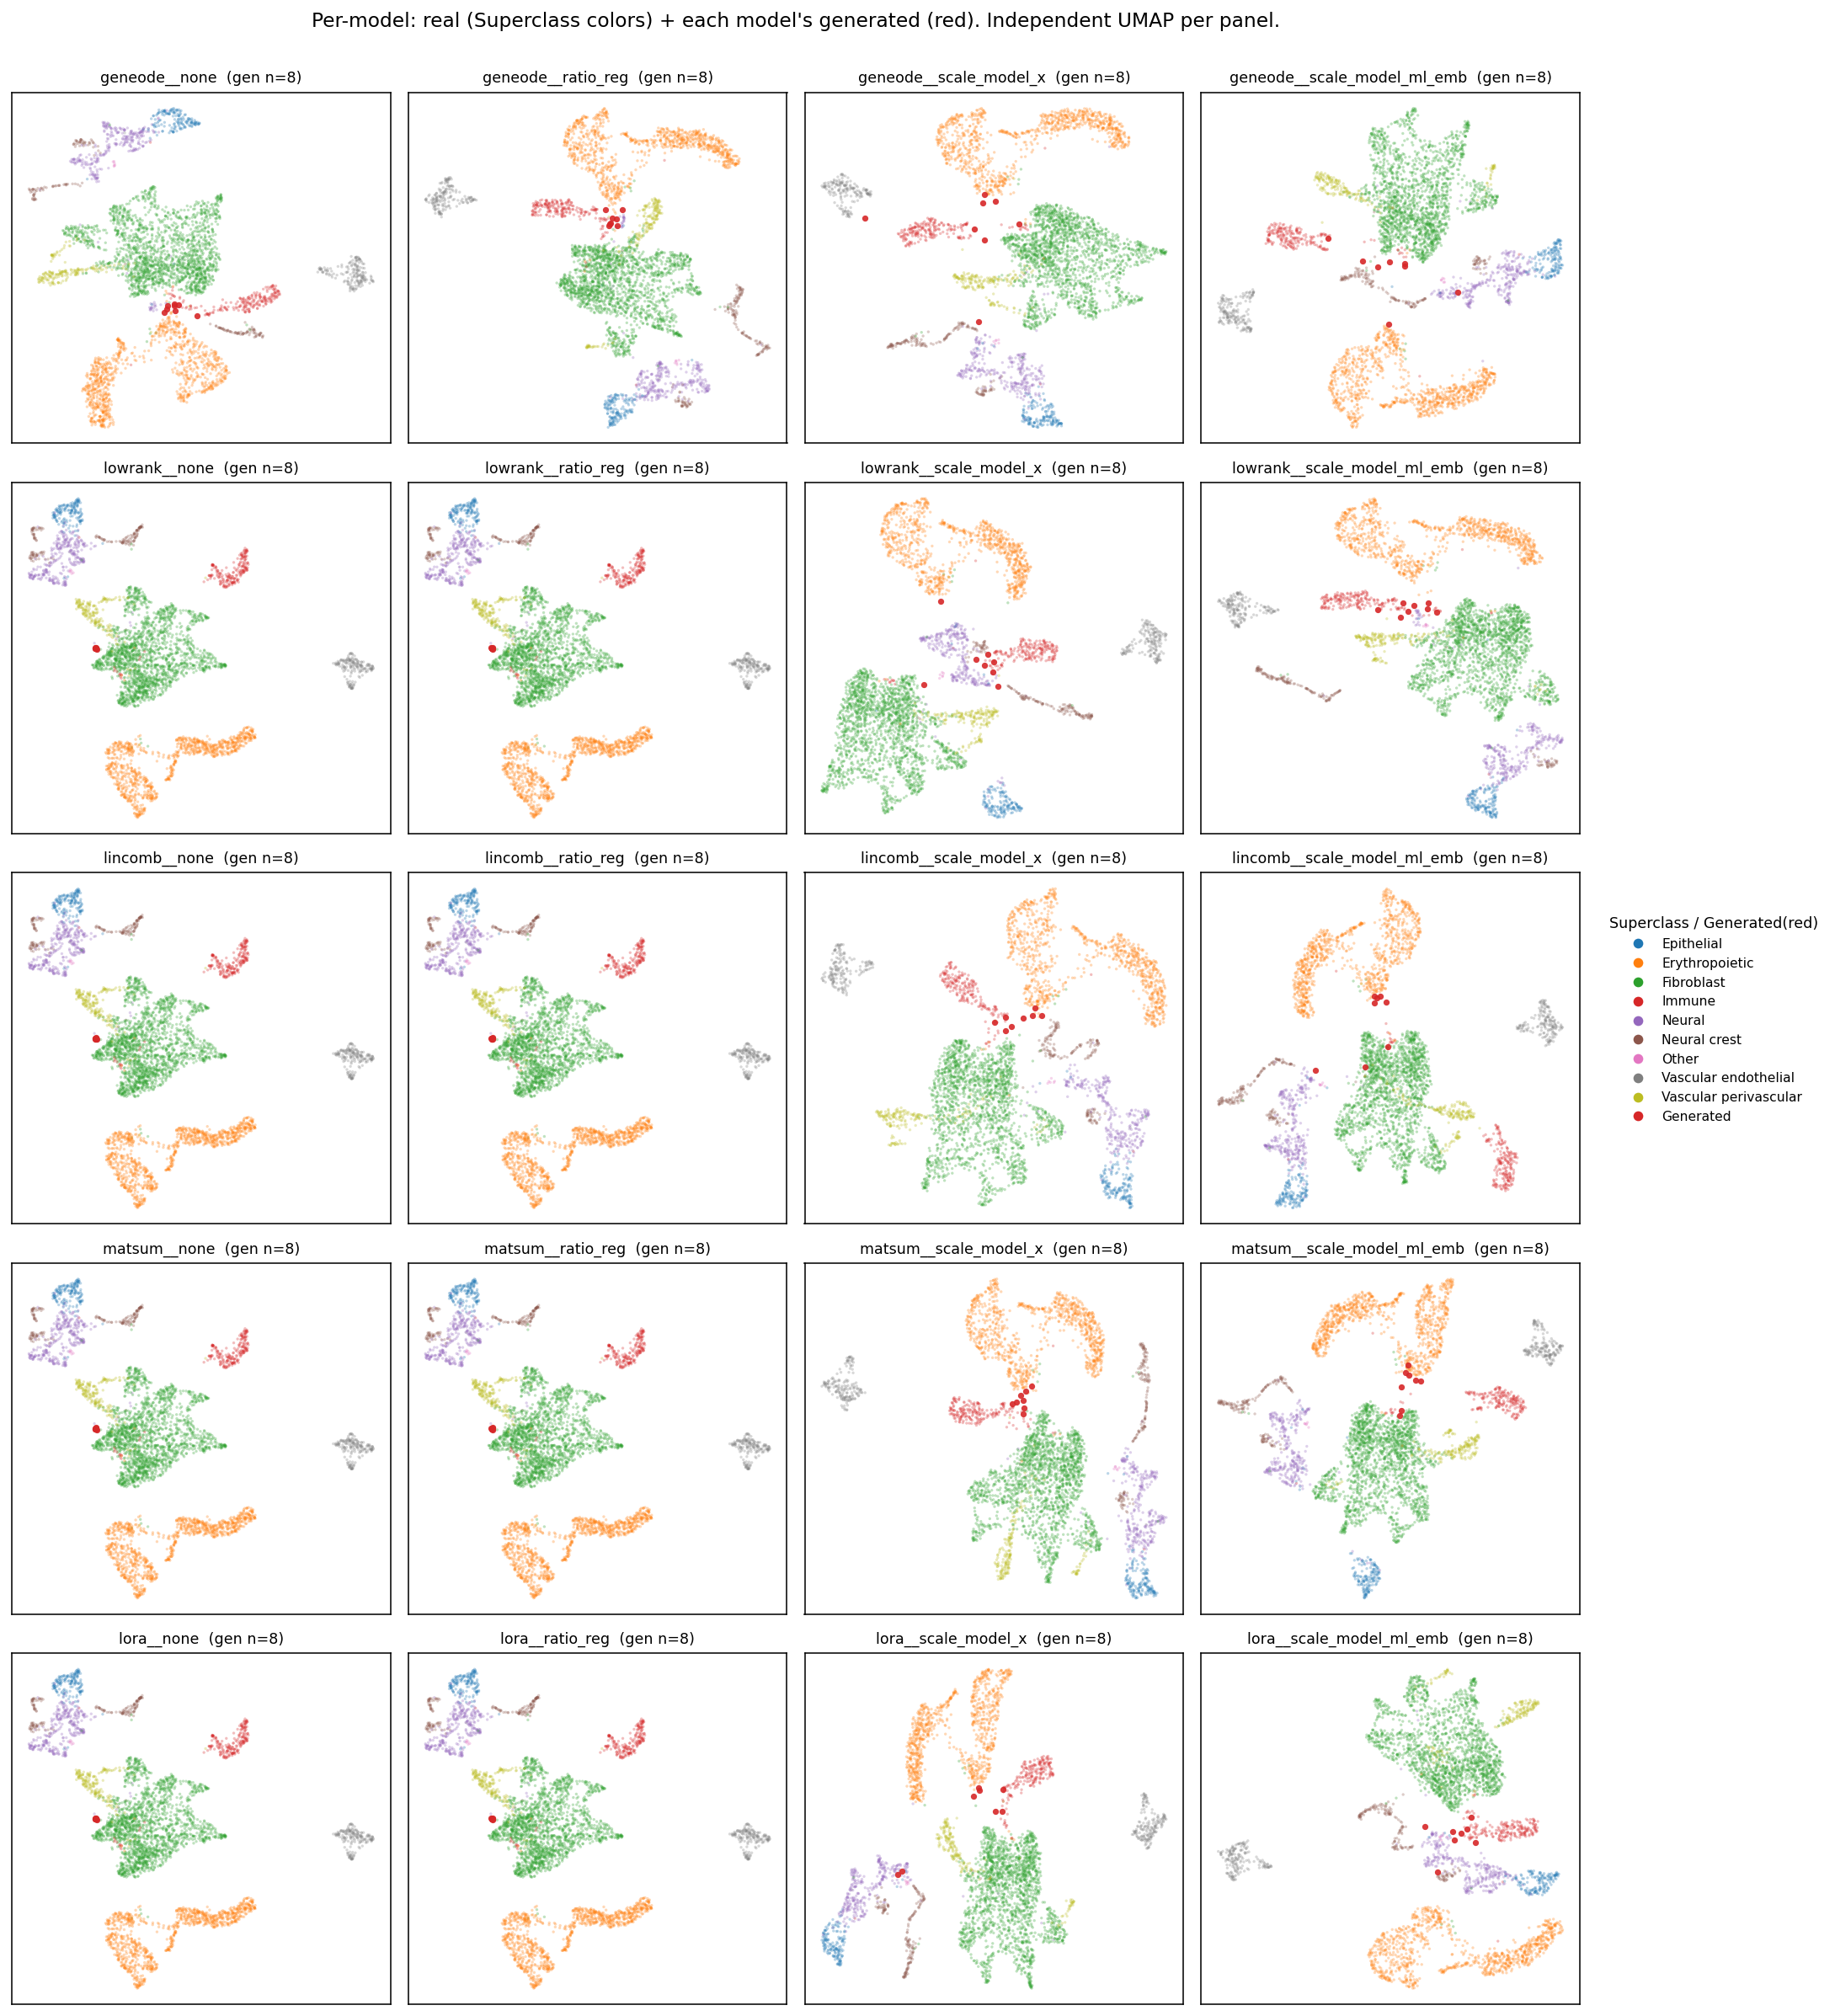

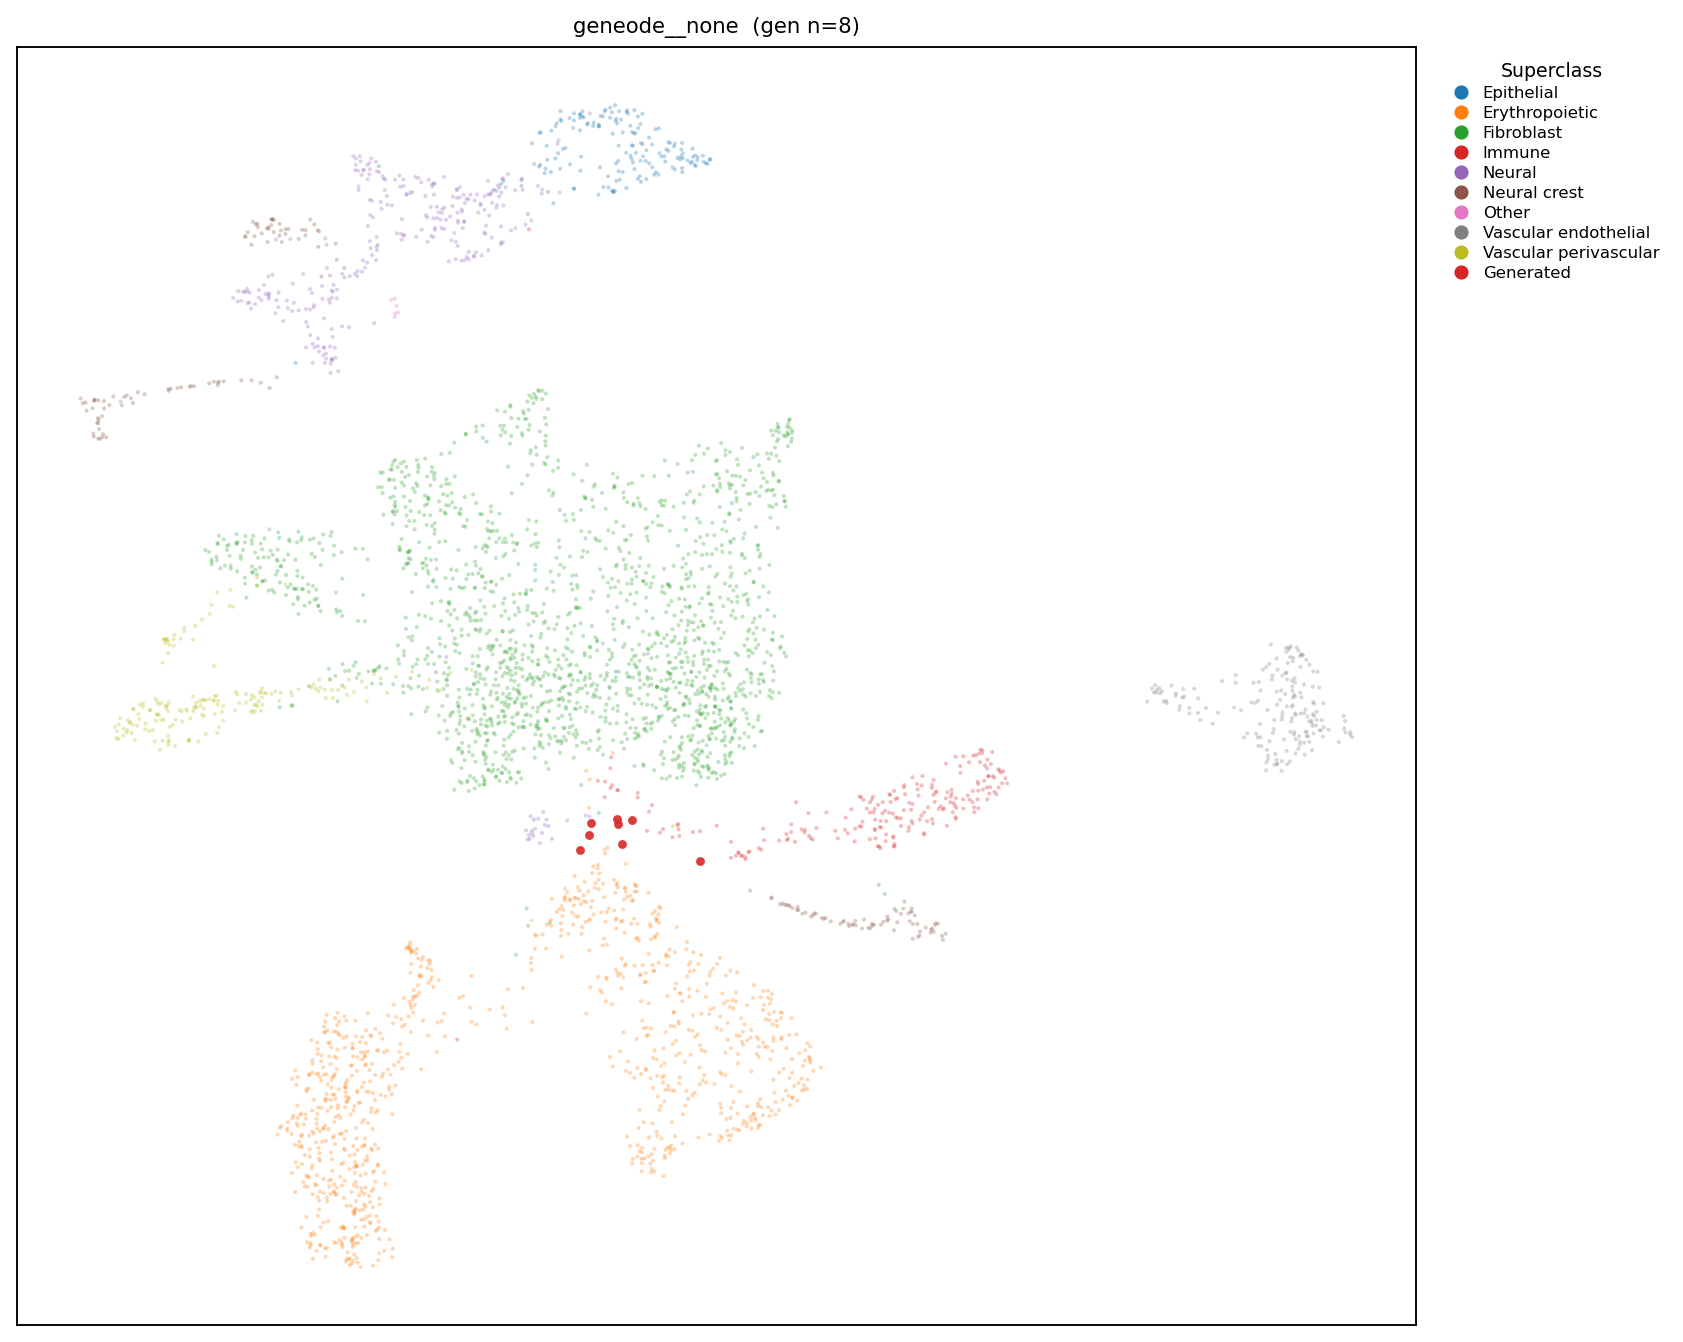

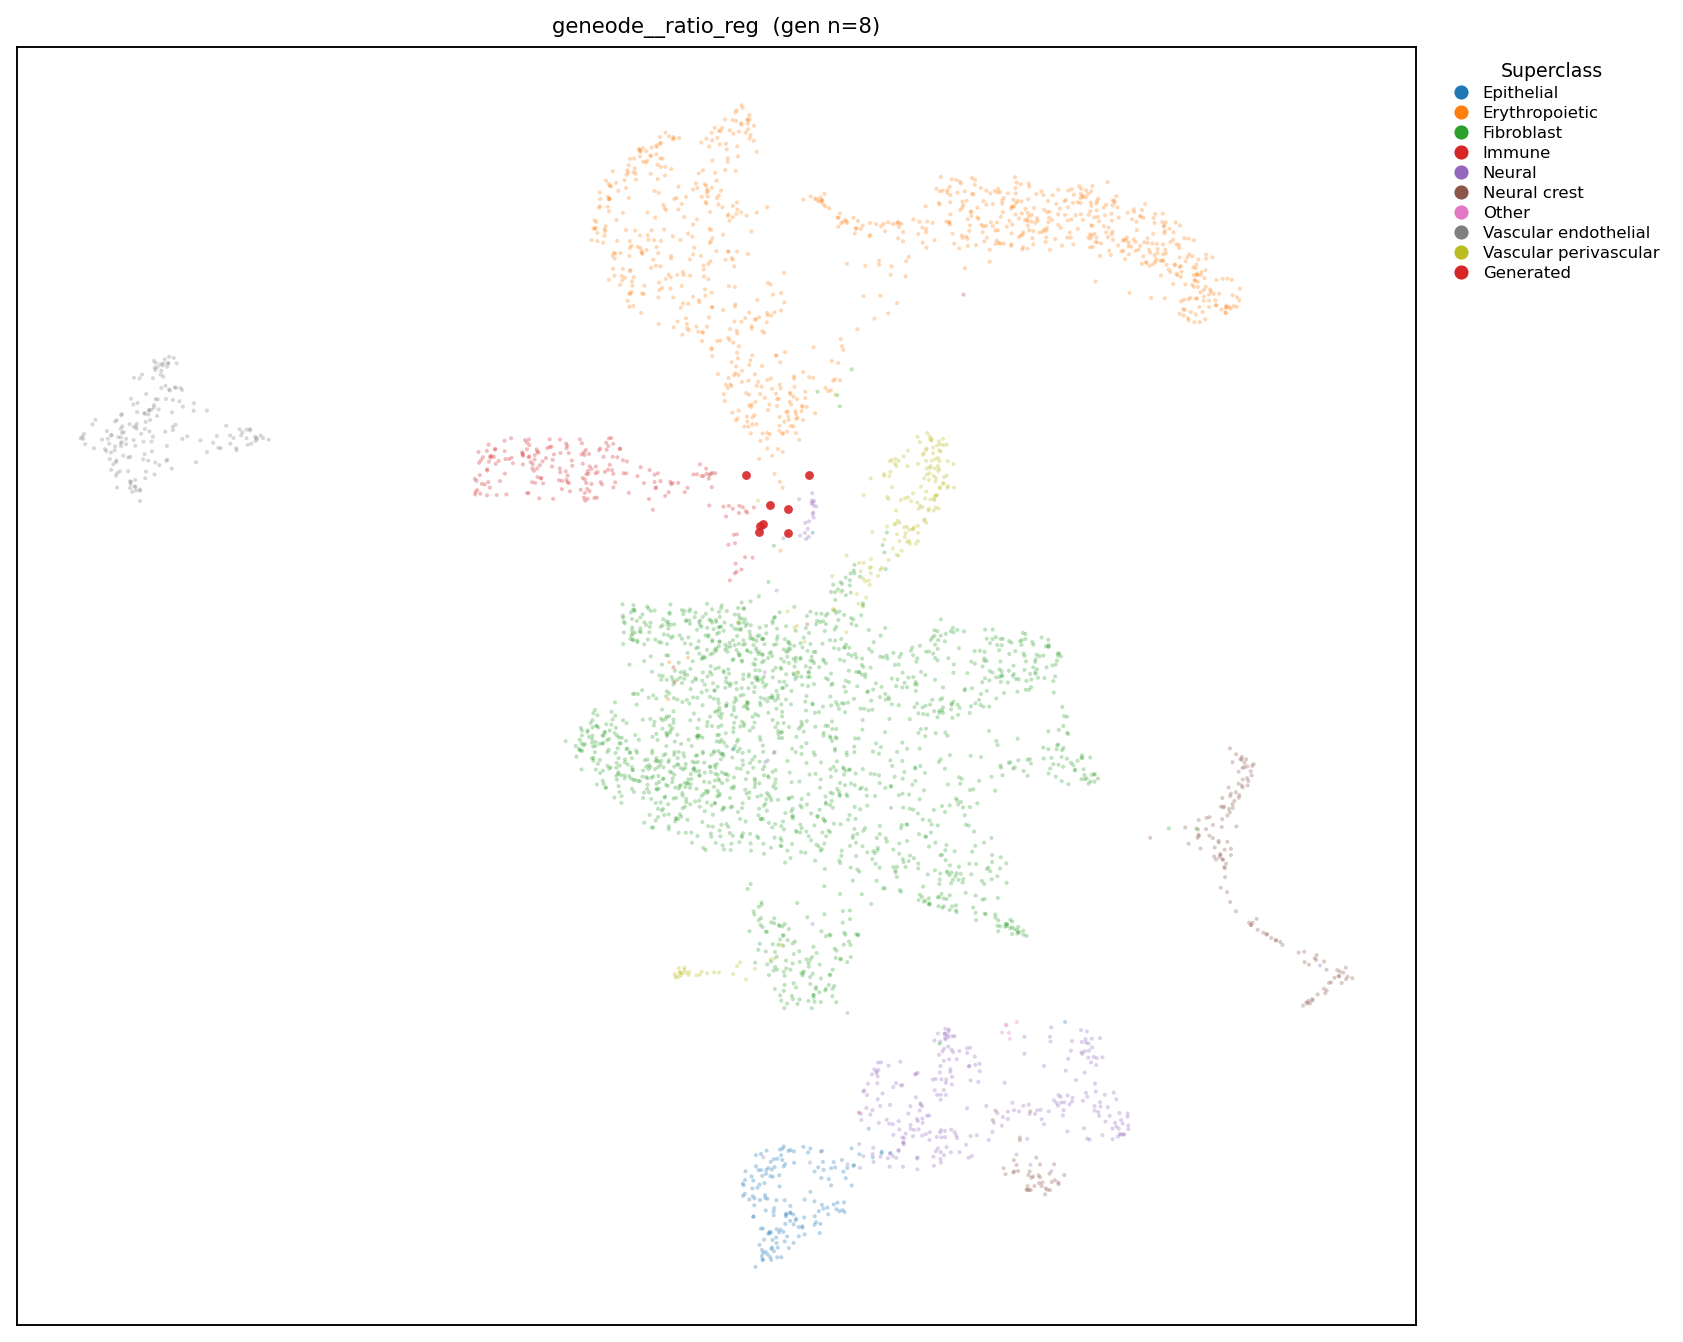

In [5]:
# 5) === A) per-model（real=Superclass色 + その model の gen=赤）-> 20枚 + facets ===
from IPython.display import Image, display
pm_ps = dict(size_real=3, size_gen=14, alpha_real=0.3, alpha_gen=0.9)
params_pm = dict(per_model_gen_cells=PER_MODEL_GEN_CELLS, seed=SEED,
                 n_pcs=N_PCS, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST)
real_pm = U.subsample_real(adata_real, PER_MODEL_REAL_CELLS, seed=SEED)
pm_info = U.run_per_model(selected, real_pm, real_cmap, OUT_DIR, pm_ps, params_pm)
pd.DataFrame(pm_info).to_csv(os.path.join(OUT_DIR, "per_model_counts.csv"), index=False)
del real_pm
display(Image(filename=os.path.join(OUT_DIR, "per_model", "all_models_facets.png")))
for L in list(selected)[:2]:
    display(Image(filename=os.path.join(OUT_DIR, "per_model", f"{L}.png")))


[real] subsample 156726 -> 20000
[gen] geneode__none: 8 cells
[gen] geneode__ratio_reg: 8 cells
[gen] geneode__scale_model_x: 8 cells
[gen] geneode__scale_model_ml_emb: 8 cells
[gen] lowrank__none: 8 cells
[gen] lowrank__ratio_reg: 8 cells
[gen] lowrank__scale_model_x: 8 cells
[gen] lowrank__scale_model_ml_emb: 8 cells
[gen] lincomb__none: 8 cells
[gen] lincomb__ratio_reg: 8 cells
[gen] lincomb__scale_model_x: 8 cells
[gen] lincomb__scale_model_ml_emb: 8 cells
[gen] matsum__none: 8 cells
[gen] matsum__ratio_reg: 8 cells
[gen] matsum__scale_model_x: 8 cells
[gen] matsum__scale_model_ml_emb: 8 cells
[gen] lora__none: 8 cells
[gen] lora__ratio_reg: 8 cells
[gen] lora__scale_model_x: 8 cells
[gen] lora__scale_model_ml_emb: 8 cells


/Users/cls-lab/miniconda3/envs/scdiffusion/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/cls-lab/miniconda3/envs/scdiffusion/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[integrated] saved real_annotation / origin / branch_marker_variant_color / summary_side_by_side


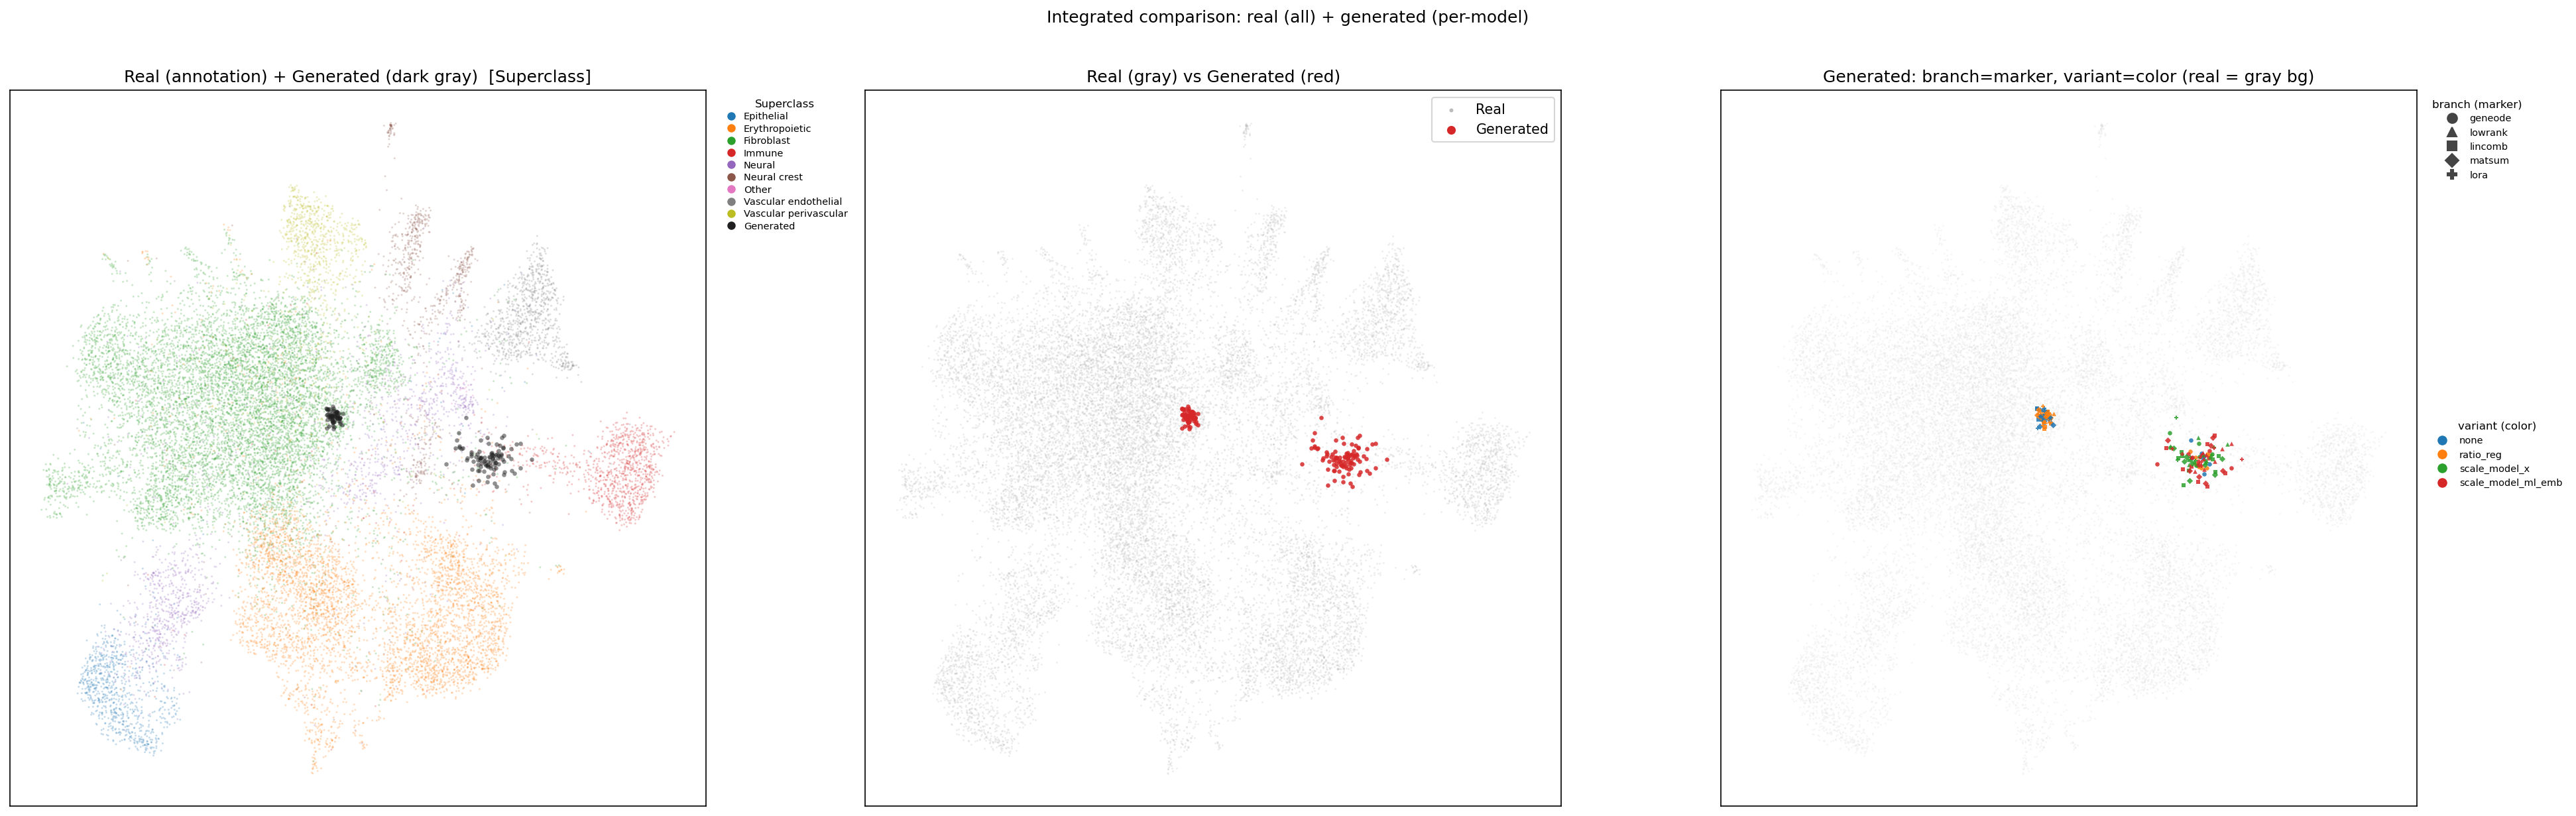

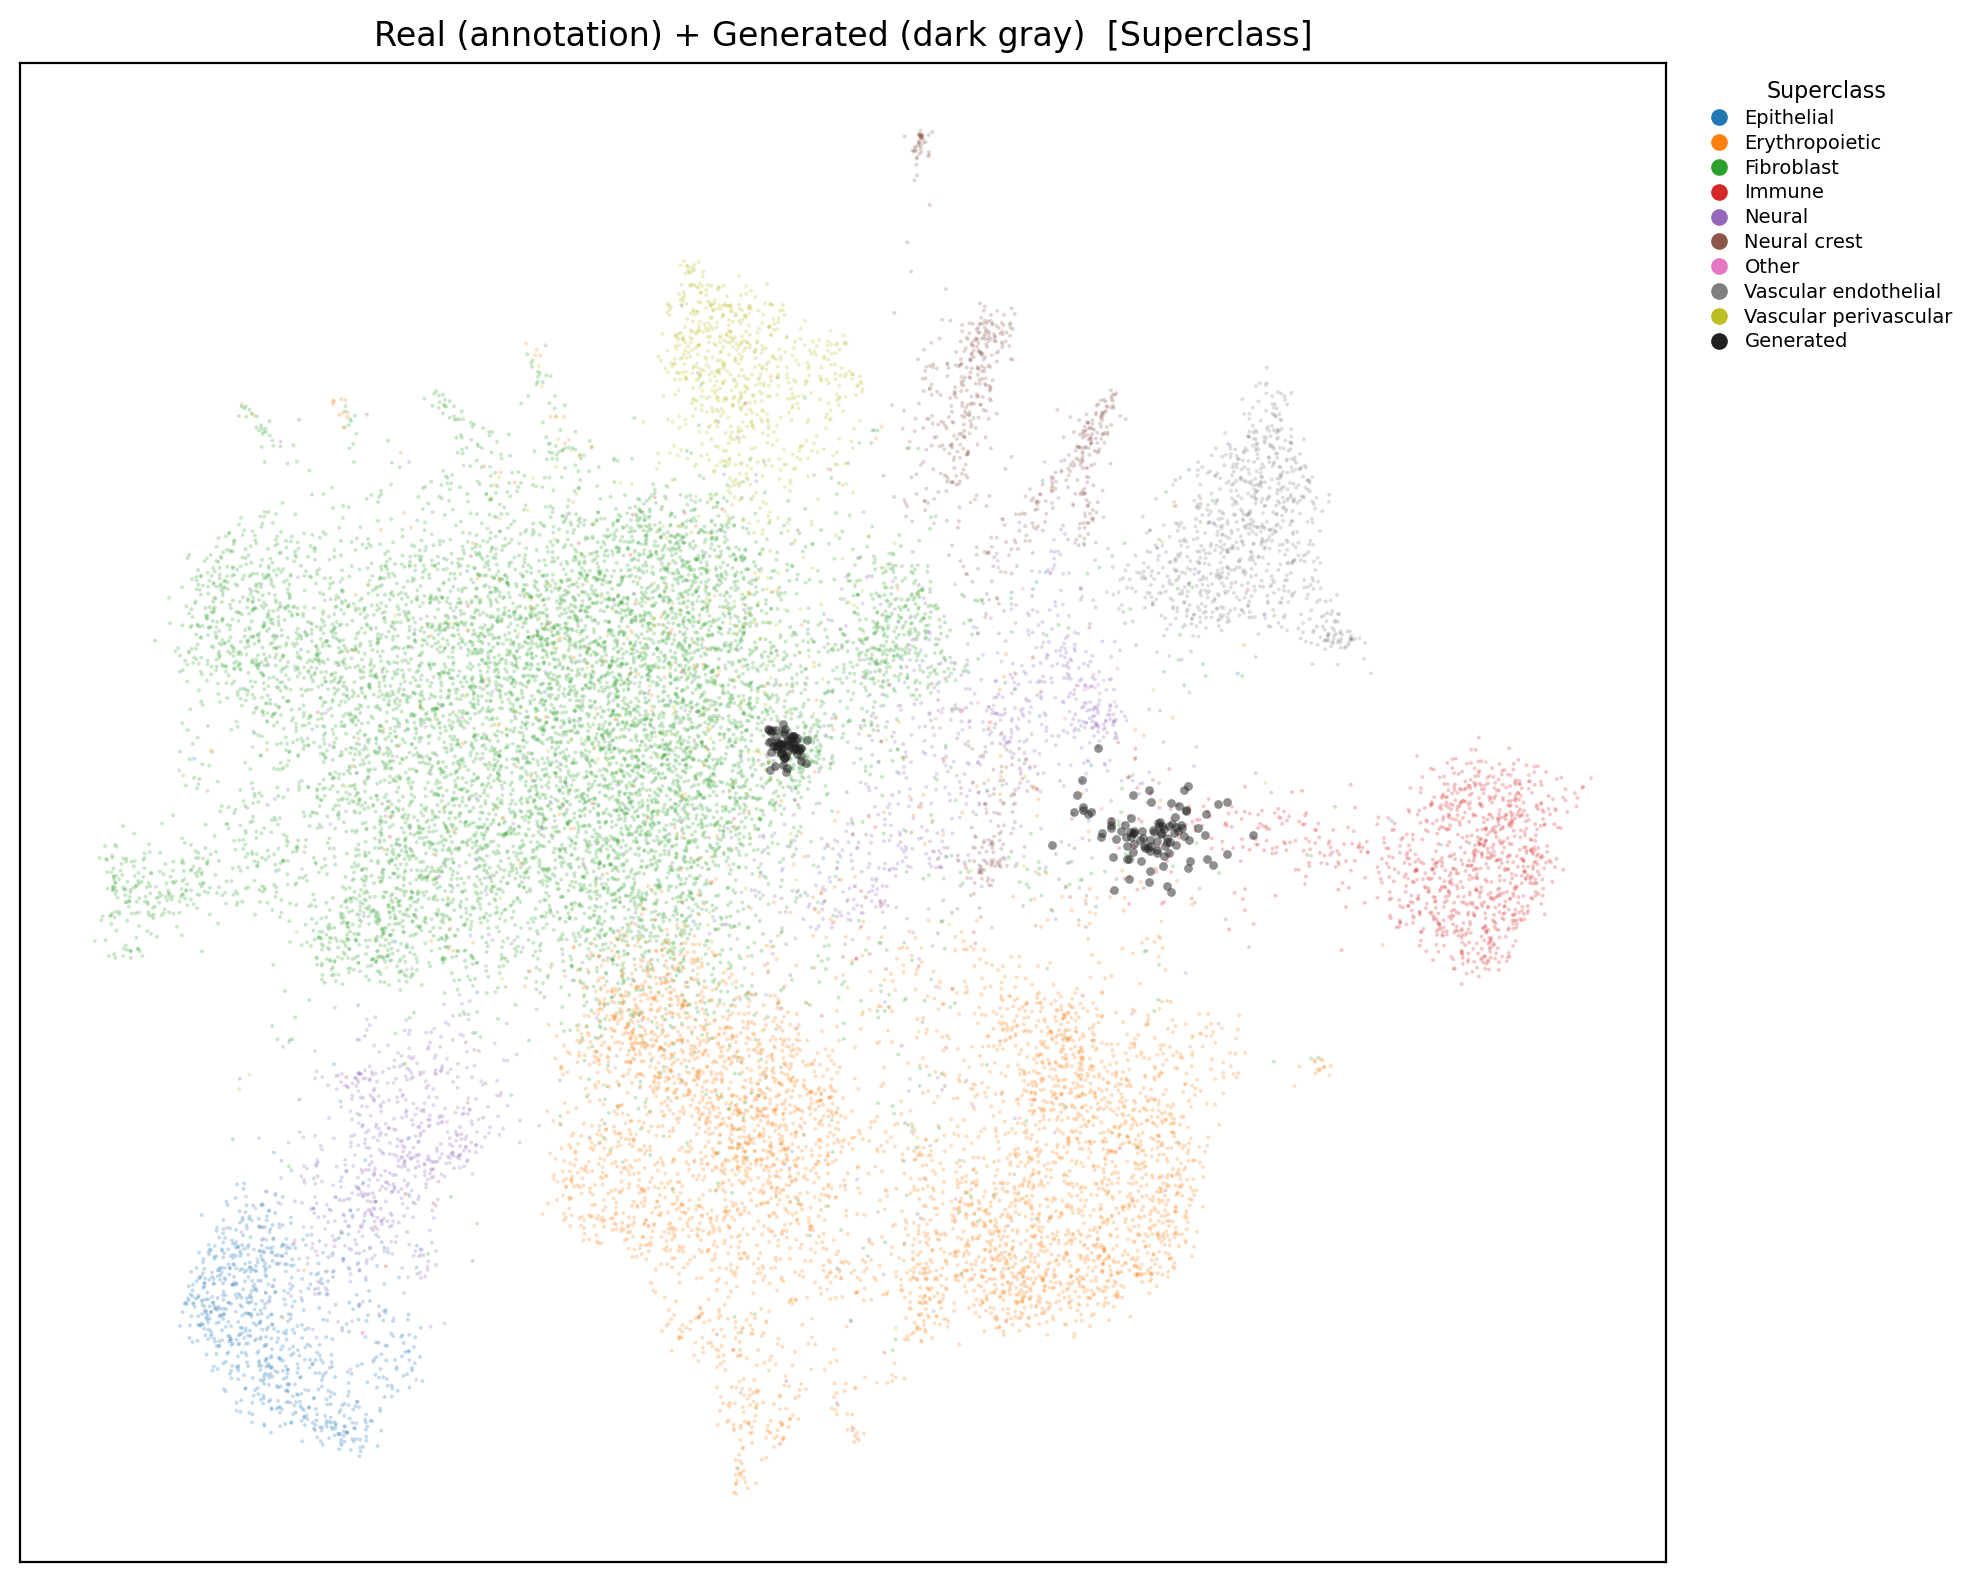

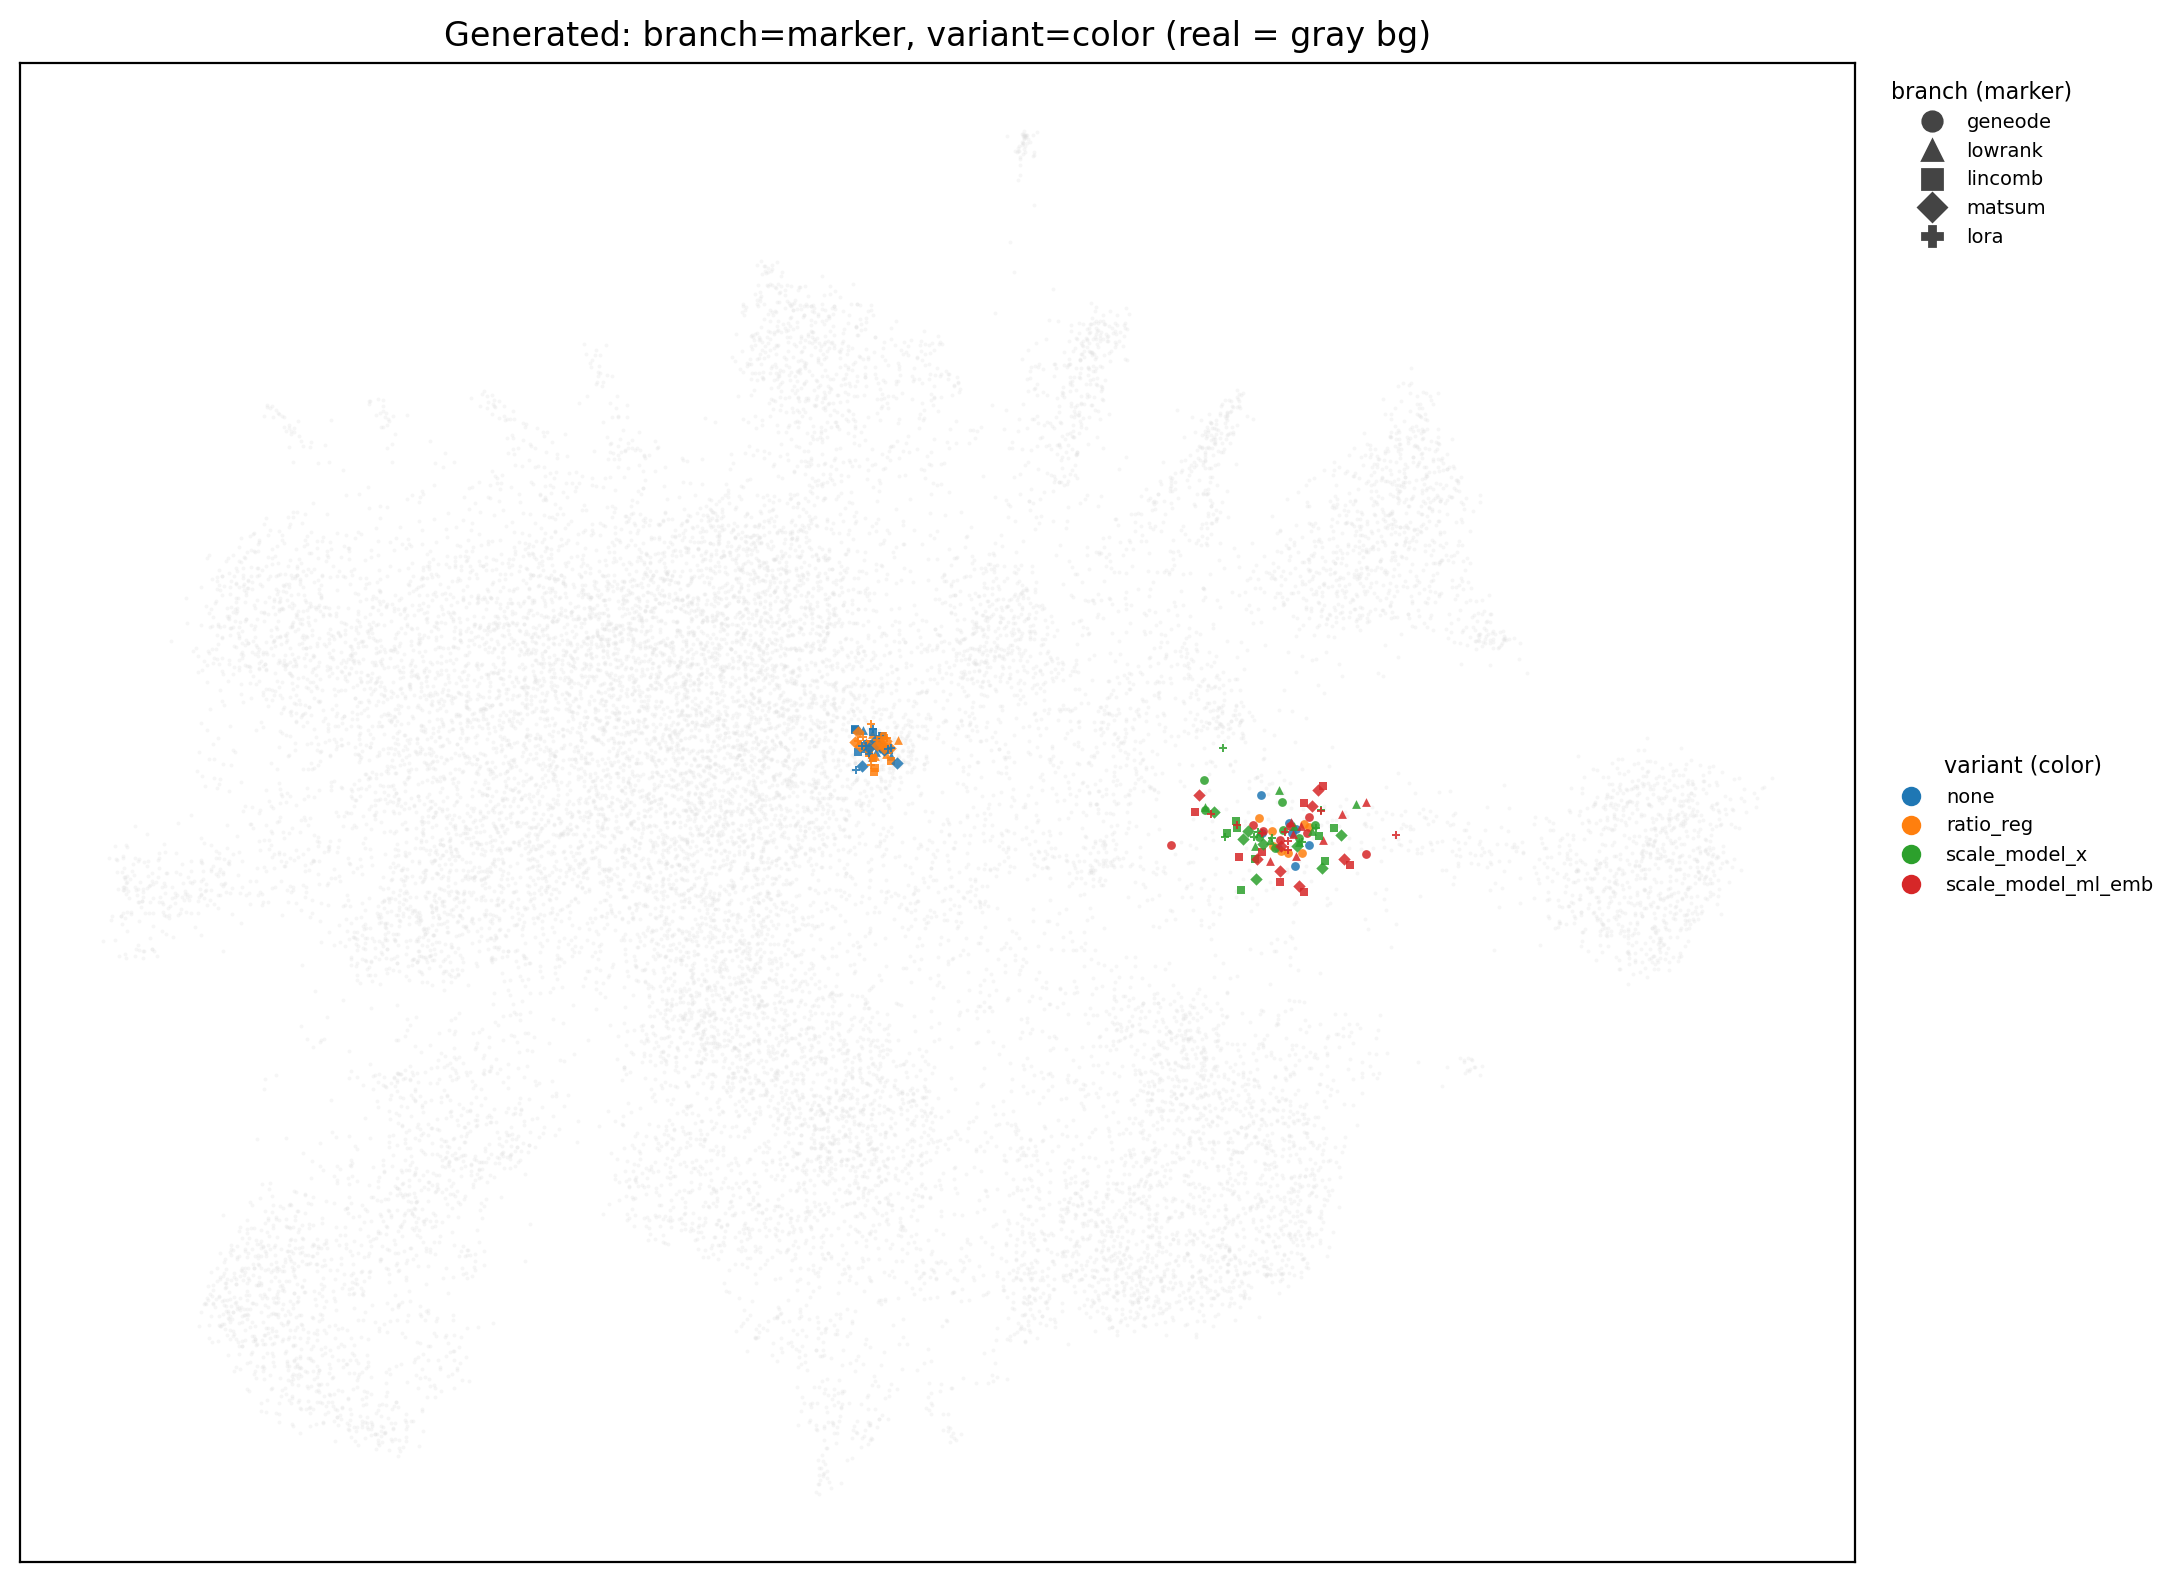

In [6]:
# 6) === B) integrated（real 全部 + 全 model の gen 500）-> overlay 4 + summary ===
int_ps = dict(size_real=2, size_gen=10, alpha_real=0.25, alpha_gen=0.85)
real_int = U.subsample_real(adata_real, INTEGRATED_REAL_CELLS, seed=SEED)
gen_int, gen_counts = U.load_gen_all(selected, INTEGRATED_GEN_PER_MODEL, seed=SEED,
                                     n_vars_expected=adata_real.n_vars)
combined = U.build_combined(real_int, gen_int)
combined = U.compute_umap(combined, n_pcs=N_PCS, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, seed=SEED)
U.plot_integrated_overlays(combined, real_cmap, variant_cmap, branch_marker_map,
                           os.path.join(OUT_DIR, "integrated"), int_ps, annotation_col=ann_col)
for name in ("integrated_summary_side_by_side.png", "integrated_real_annotation.png",
             "integrated_branch_marker_variant_color.png"):
    display(Image(filename=os.path.join(OUT_DIR, "integrated", name)))


In [7]:
# 7) outputs 一覧
print("outputs in:", OUT_DIR)
for root, _, files in os.walk(OUT_DIR):
    for f in sorted(files):
        print("  ", os.path.relpath(os.path.join(root, f), OUT_DIR))


outputs in: outputs/20260620_225600
   branch_marker_map.csv
   color_map_real_annotation.csv
   model_color_map.csv
   per_model_counts.csv
   run_config.json
   selected_runs.csv
   selected_runs_config.json
   skipped_runs.csv
   variant_color_map.csv
   per_model/all_models_facets.png
   per_model/geneode__none.png
   per_model/geneode__ratio_reg.png
   per_model/geneode__scale_model_ml_emb.png
   per_model/geneode__scale_model_x.png
   per_model/lincomb__none.png
   per_model/lincomb__ratio_reg.png
   per_model/lincomb__scale_model_ml_emb.png
   per_model/lincomb__scale_model_x.png
   per_model/lora__none.png
   per_model/lora__ratio_reg.png
   per_model/lora__scale_model_ml_emb.png
   per_model/lora__scale_model_x.png
   per_model/lowrank__none.png
   per_model/lowrank__ratio_reg.png
   per_model/lowrank__scale_model_ml_emb.png
   per_model/lowrank__scale_model_x.png
   per_model/matsum__none.png
   per_model/matsum__ratio_reg.png
   per_model/matsum__scale_model_ml_emb.png
   pe